# Depth EDA Notebook

Inspect predicted depth outputs from `estimate_depth.py`, verify spatial alignment with the input frame, and run practical depth quality EDA.


In [1]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

plt.style.use('seaborn-v0_8')
np.set_printoptions(suppress=True, precision=4)


In [3]:
# Change this to inspect a different run
VIDEO_NAME = 'video_01'

SCRIPT_DIR = Path('.').resolve()
OUTPUT_ROOT = SCRIPT_DIR / 'output'
RUN_DIR = OUTPUT_ROOT / VIDEO_NAME

FRAME_PATH = RUN_DIR / 'frame_00.png'
METRIC_DEPTH_PATH = RUN_DIR / 'metric_depth.npy'
REL_DEPTH_PATH = RUN_DIR / 'relative_depth.npy'
POSE_JSON_PATH = RUN_DIR / 'pose_estimation.json'
SUMMARY_JSON_PATH = RUN_DIR / 'run_summary.json'

required = [FRAME_PATH, METRIC_DEPTH_PATH, REL_DEPTH_PATH, POSE_JSON_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Missing files:' + '\n'.join(missing))  

print('Run dir:', RUN_DIR)
print('Found files:')
for p in required:
    print(' -', p.name)


Run dir: /my_workspace/4DHHOI/4DHOI/Estimate_Depth/output/video_01
Found files:
 - frame_00.png
 - metric_depth.npy
 - relative_depth.npy
 - pose_estimation.json


In [4]:
def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f'Failed to read image: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def robust_minmax(depth: np.ndarray, pmin: float = 1.0, pmax: float = 99.0) -> tuple[float, float]:
    valid = np.isfinite(depth) & (depth > 0)
    if valid.sum() == 0:
        return 0.0, 1.0
    vals = depth[valid]
    lo = float(np.percentile(vals, pmin))
    hi = float(np.percentile(vals, pmax))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(vals.min())
        hi = float(vals.max())
    if hi <= lo:
        hi = lo + 1e-6
    return lo, hi

def colorize_depth(depth: np.ndarray, cmap: str = 'turbo', pmin: float = 1.0, pmax: float = 99.0) -> np.ndarray:
    lo, hi = robust_minmax(depth, pmin=pmin, pmax=pmax)
    d = np.clip((depth - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    d = np.nan_to_num(d, nan=0.0, posinf=1.0, neginf=0.0)
    cm = plt.get_cmap(cmap)
    rgb = (cm(d)[..., :3] * 255).astype(np.uint8)
    return rgb

def overlay_depth(frame_rgb: np.ndarray, depth: np.ndarray, alpha: float = 0.45, cmap: str = 'turbo') -> np.ndarray:
    depth_rgb = colorize_depth(depth, cmap=cmap)
    return np.clip((1 - alpha) * frame_rgb + alpha * depth_rgb, 0, 255).astype(np.uint8)

def depth_stats(depth: np.ndarray, name: str) -> dict:
    valid = np.isfinite(depth) & (depth > 0)
    vals = depth[valid]
    out = {
        'name': name,
        'shape': tuple(depth.shape),
        'num_pixels': int(depth.size),
        'valid_pixels': int(valid.sum()),
        'valid_ratio': float(valid.mean()),
    }
    if vals.size == 0:
        out.update({'min': np.nan, 'max': np.nan, 'mean': np.nan, 'median': np.nan, 'std': np.nan})
        return out

    qs = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
    out.update({
        'min': float(vals.min()),
        'max': float(vals.max()),
        'mean': float(vals.mean()),
        'median': float(np.median(vals)),
        'std': float(vals.std()),
    })
    for q in qs:
        out[f'q{q:02d}'] = float(np.percentile(vals, q))
    return out

def edge_agreement(frame_rgb: np.ndarray, depth: np.ndarray) -> dict:
    gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
    img_edges = cv2.Canny(gray, 100, 200) > 0

    lo, hi = robust_minmax(depth, 1, 99)
    d_norm = np.clip((depth - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    d_u8 = (d_norm * 255).astype(np.uint8)
    d_edges = cv2.Canny(d_u8, 40, 120) > 0

    inter = np.logical_and(img_edges, d_edges).sum()
    union = np.logical_or(img_edges, d_edges).sum()
    prec = inter / max(d_edges.sum(), 1)
    rec = inter / max(img_edges.sum(), 1)
    iou = inter / max(union, 1)

    return {
        'image_edge_pixels': int(img_edges.sum()),
        'depth_edge_pixels': int(d_edges.sum()),
        'intersection': int(inter),
        'edge_precision': float(prec),
        'edge_recall': float(rec),
        'edge_iou': float(iou),
        'image_edges': img_edges,
        'depth_edges': d_edges,
    }


In [5]:
frame_rgb = load_rgb(FRAME_PATH)
metric_depth = np.load(METRIC_DEPTH_PATH).astype(np.float32)
relative_depth = np.load(REL_DEPTH_PATH).astype(np.float32)

with open(POSE_JSON_PATH, 'r', encoding='utf-8') as f:
    pose_data = json.load(f)

summary_data = None
if SUMMARY_JSON_PATH.exists():
    with open(SUMMARY_JSON_PATH, 'r', encoding='utf-8') as f:
        summary_data = json.load(f)

print('Frame shape        :', frame_rgb.shape)
print('Metric depth shape :', metric_depth.shape)
print('Relative depth shape:', relative_depth.shape)
print('Aligned to frame?  :', metric_depth.shape[:2] == frame_rgb.shape[:2])
if summary_data is not None and 'process_res_used' in summary_data:
    print('process_res_used   :', summary_data['process_res_used'])


Frame shape        : (720, 1280, 3)
Metric depth shape : (720, 1280)
Relative depth shape: (720, 1280)
Aligned to frame?  : True
process_res_used   : 1280


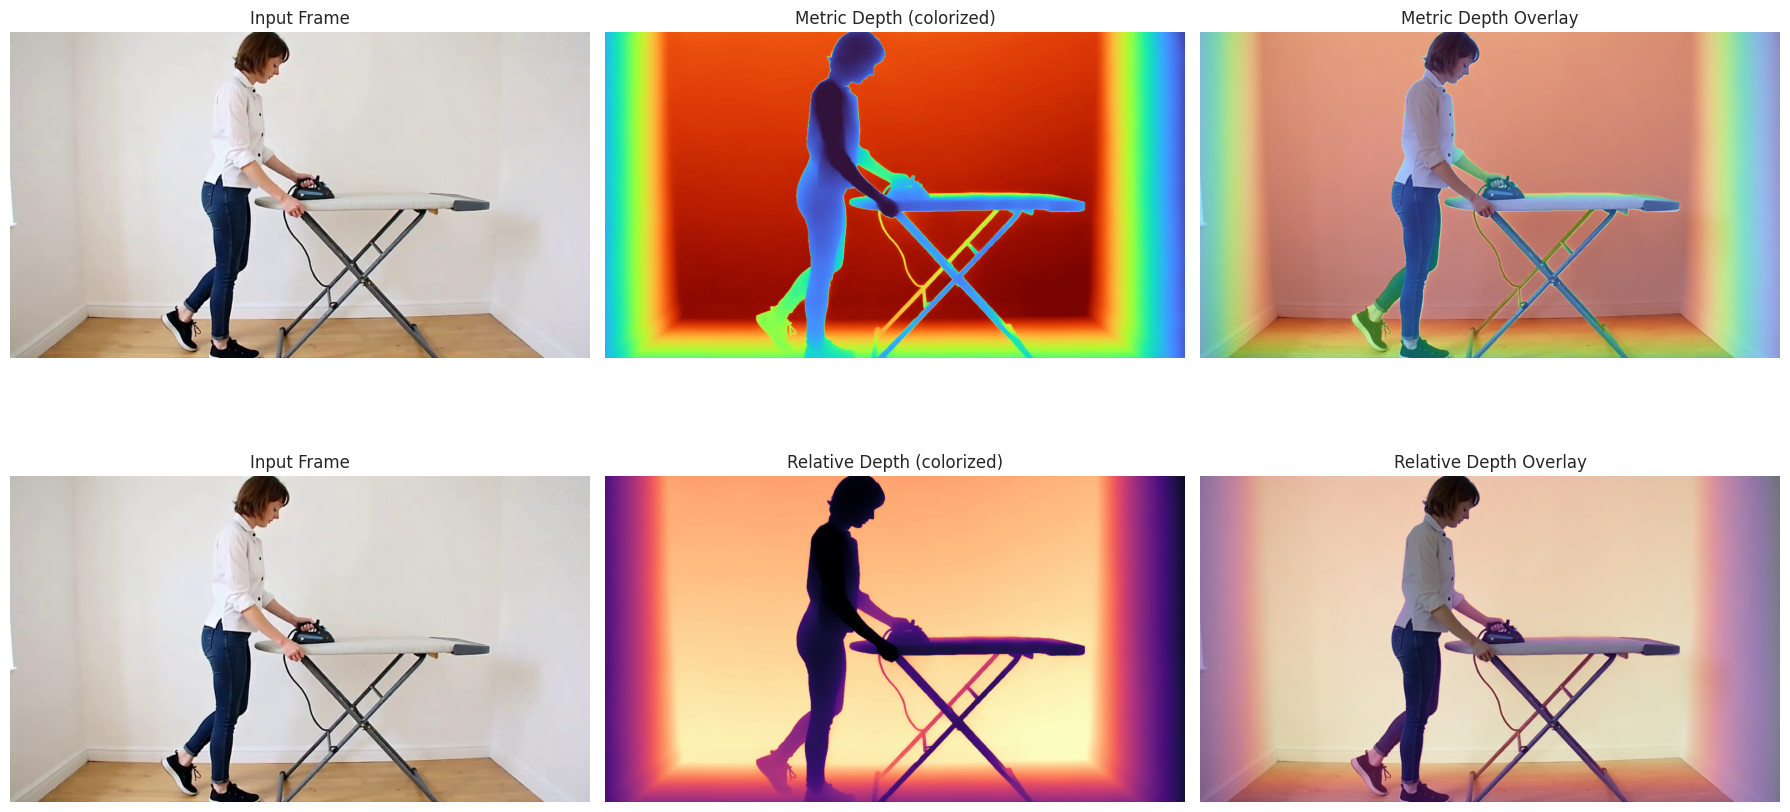

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].imshow(frame_rgb)
ax[0, 0].set_title('Input Frame')
ax[0, 1].imshow(colorize_depth(metric_depth, cmap='turbo'))
ax[0, 1].set_title('Metric Depth (colorized)')
ax[0, 2].imshow(overlay_depth(frame_rgb, metric_depth, alpha=0.45, cmap='turbo'))
ax[0, 2].set_title('Metric Depth Overlay')

ax[1, 0].imshow(frame_rgb)
ax[1, 0].set_title('Input Frame')
ax[1, 1].imshow(colorize_depth(relative_depth, cmap='magma'))
ax[1, 1].set_title('Relative Depth (colorized)')
ax[1, 2].imshow(overlay_depth(frame_rgb, relative_depth, alpha=0.45, cmap='magma'))
ax[1, 2].set_title('Relative Depth Overlay')

for a in ax.ravel():
    a.axis('off')
plt.tight_layout()
plt.show()


In [7]:
metric_stats = depth_stats(metric_depth, 'metric_depth')
relative_stats = depth_stats(relative_depth, 'relative_depth')

if pd is not None:
    display(pd.DataFrame([metric_stats, relative_stats]).T)
else:
    print('Metric stats:\n', json.dumps(metric_stats, indent=2))
    print('Relative stats:\n', json.dumps(relative_stats, indent=2))


,0,1
name,metric_depth,relative_depth
shape,"(720, 1280)","(720, 1280)"
num_pixels,921600,921600
valid_pixels,921600,921600
valid_ratio,1.0,1.0
min,1.737805,0.668605
max,2.684023,1.032653
mean,2.378287,0.915024
median,2.514545,0.967448
std,0.263499,0.101379
